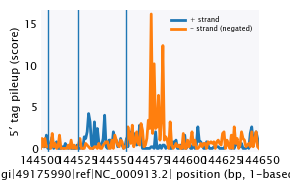

In [9]:
from __future__ import annotations

import gzip
import re
from dataclasses import dataclass
from pathlib import Path
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Tuple
import regseq2

regseq2.viz.matplotlib_style()

import numpy as np
import matplotlib.pyplot as plt

# --- filename grouping ---
FILENAME_RE = re.compile(
    r"GSM\d+_ChIPExo-Crp_"
    r"(?P<genotype>[^_]+)_"
    r"(?P<carbon>[^_]+)_NH4Cl_O2_"
    r"(?P<rep>\d+)_anti-crp\.gff\.gz$"
)

def group_gff_files(base_dir: Path) -> Dict[Tuple[str, str], List[Path]]:
    groups = defaultdict(list)
    for p in sorted(base_dir.glob("*anti-crp.gff.gz")):
        m = FILENAME_RE.match(p.name)
        if not m:
            raise ValueError(f"Unexpected filename pattern: {p.name}")
        groups[(m["genotype"], m["carbon"])].append(p)
    return groups

# --- GFF reading ---
@dataclass(frozen=True)
class GffRec:
    seqid: str
    start: int
    end: int
    score: Optional[float]
    strand: str

def iter_gff_gz(path: Path) -> Iterable[GffRec]:
    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            if not line or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 9:
                continue
            seqid, _, _, start, end, score, strand, _, _ = parts
            yield GffRec(
                seqid=seqid,
                start=int(start),
                end=int(end),
                score=None if score == "." else float(score),
                strand=strand,
            )

def detect_seqid(gff_path: Path) -> str:
    for rec in iter_gff_gz(gff_path):
        return rec.seqid
    raise ValueError(f"No records found in {gff_path}")

def extract_interval_signal(gff_path: Path, seqid: str, start: int, end: int):
    x = np.arange(start, end + 1, dtype=np.int64)
    plus = np.zeros_like(x, dtype=np.float64)
    minus = np.zeros_like(x, dtype=np.float64)
    idx0 = start

    for rec in iter_gff_gz(gff_path):
        if rec.seqid != seqid or rec.score is None:
            continue
        if rec.end < start or rec.start > end:
            continue

        s = max(rec.start, start)
        e = min(rec.end, end)

        # Most records are 1 bp (start=end). If not, distribute uniformly.
        v_per_base = rec.score if rec.start == rec.end else rec.score / (rec.end - rec.start + 1)

        if rec.strand == "+":
            plus[(s - idx0):(e - idx0 + 1)] += v_per_base
        elif rec.strand == "-":
            minus[(s - idx0):(e - idx0 + 1)] += v_per_base
        else:
            plus[(s - idx0):(e - idx0 + 1)] += v_per_base

    return x, plus, minus

def mean_signal(files: List[Path], seqid: str, start: int, end: int):
    pls, mis = [], []
    x_ref = None
    for p in files:
        x, pl, mi = extract_interval_signal(p, seqid, start, end)
        x_ref = x if x_ref is None else x_ref
        pls.append(pl)
        mis.append(mi)
    return x_ref, np.mean(np.vstack(pls), axis=0), np.mean(np.vstack(mis), axis=0)

# --- plot yadI region ---
data_dir = Path("../../data/chip-seq/")
groups = group_gff_files(data_dir)

# Use WT fructose (you have 5 replicates)
files = groups[("wt", "fructose")]

seqid = detect_seqid(files[0])  # should be gi|49175990|ref|NC_000913.2|
yadI_start, yadI_end = 144_577, 145_017
start, end = 144_500, 144_650  # window around yadI

x, pl, mi = mean_signal(files, seqid, start, end)

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(x, pl, linewidth=2, label="+ strand")
ax.plot(x, -mi, linewidth=2, label="- strand (negated)")
plt.axvline(144559, linewidth=1)
plt.axvline(144526, linewidth=1)
plt.axvline(144505, linewidth=1)

#plt.axvspan(yadI_start, yadI_end, alpha=0.2, label="yadI gene body")
ax.set_xlim(start, end)
ax.set_xlabel(f"{seqid} position (bp, 1-based)")
ax.set_ylabel("5′ tag pileup (score)")
#plt.title("CRP ChIP-exo signal at yadI (wt, fructose, mean over replicates)")
ax.legend(frameon=False)

plt.tight_layout()

fig.savefig('yadI_scores.pdf')
